# Creación de datos de entrenamiento

## 1. Configuración de entorno

In [ ]:
# Importar el paquete GeoAI
import os

import geoai

%config Completer.use_jedi = False

In [ ]:
# Especificar las carpetas
train_path = "../geoai/train"
images_path = f"{train_path}/images"
masks_path = f"{train_path}/masks"

## 2. Comprobación de datos

In [ ]:
# Mostrar los archivos en las carpetas
print("Capas ráster:")
for i in sorted(os.listdir(images_path)):
    path = os.path.join(images_path, i)
    print(f"  -{i} | Tamaño: {os.path.getsize(path)/(1024*1024):.2f} MB")

print(f"{'='*60}")

print("Capas vectoriales:")
for i in sorted(os.listdir(masks_path)):
    path = os.path.join(masks_path, i)
    print(f"  -{i} | Tamaño: {os.path.getsize(path)/(1024):.2f} kB")

Capas ráster:
  -naip_rgb_train_tile1.tif | Tamaño: 3.64 MB
  -naip_rgb_train_tile2.tif | Tamaño: 4.30 MB
  -train_2021.tif | Tamaño: 23.06 MB
  -train_2024.tif | Tamaño: 16.59 MB
Capas vectoriales:
  -naip_rgb_train_tile1.geojson | Tamaño: 103.60 kB
  -naip_rgb_train_tile2.geojson | Tamaño: 231.06 kB
  -train_2021.geojson | Tamaño: 279.81 kB
  -train_2024.geojson | Tamaño: 192.50 kB


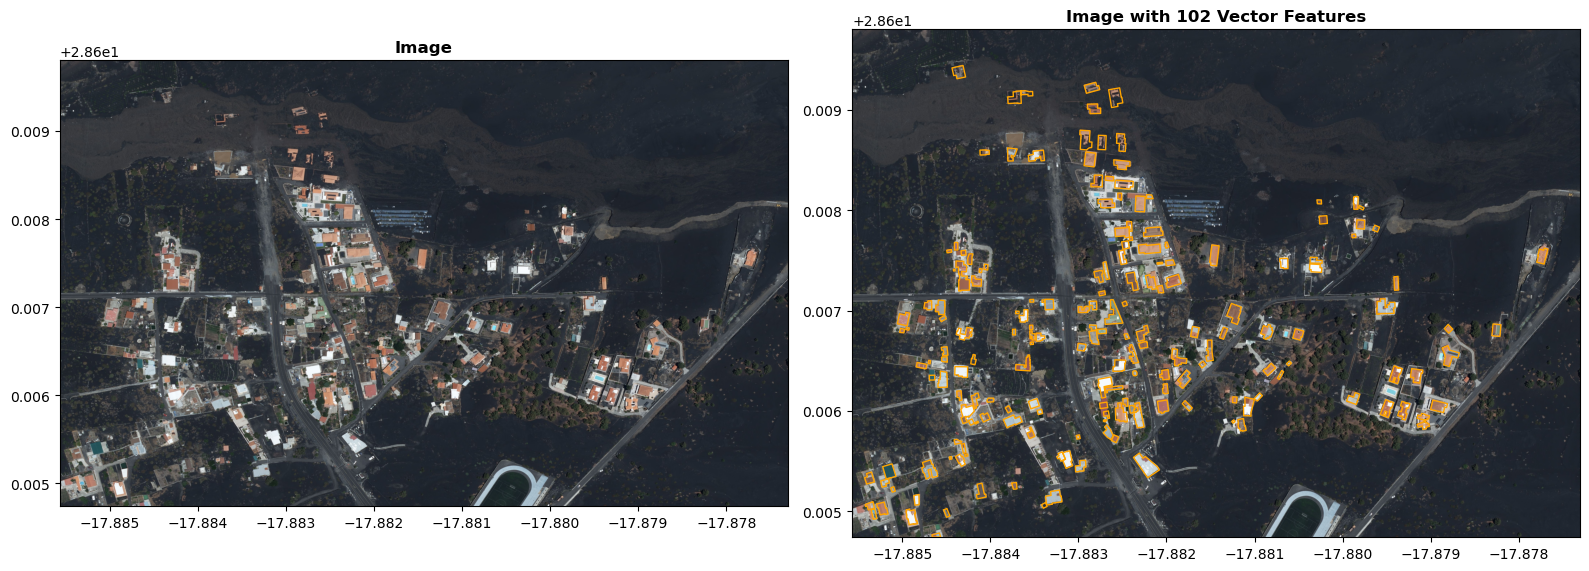


Cantidad de edificios: 102


In [ ]:
# Visualizar uno de los archivos con su vector asociado
image_example = f"{images_path}/train_2024.tif"
mask_example = f"{masks_path}/train_2024.geojson"
fig, axes, info = geoai.display_image_with_vector(
    image_example, mask_example, vector_color="orange"
)

# Contar los edificios en el área de la imagen
print(f"\n{'='*60}")
print(f"Cantidad de edificios: {info['num_features']}")

## 3. Creación de mosaicos

In [ ]:
# Exportar los mosaicos georreferenciados
stats = geoai.export_geotiff_tiles_batch(
    images_folder=images_path,
    masks_folder=masks_path,
    output_folder=f"{train_path}/output",
    tile_size=512,
    stride=256,  # Superposición del 50 % al saltar de mosaico
    class_value_field="class",
    skip_empty_tiles=True,  # Ignora los mosaicos sin edificios
    match_by_name=True,  # Procesa las imagenes y máscaras por nombre de archivo (train_2024.tif = train_2024.geojson)
)

Found 4 matching image-mask pairs to process
Processing batch from ../geoai/train/images and ../geoai/train/masks
Output folder: ../geoai/train/output
------------------------------------------------------------


Processing image pairs:   0%|                                                                                                    | 0/4 [00:00<?, ?it/s]


Processing: naip_rgb_train_tile1
  Image: naip_rgb_train_tile1.tif
  Mask: naip_rgb_train_tile1.geojson


Processing image pairs:  25%|███████████████████████                                                                     | 1/4 [00:01<00:03,  1.12s/it]


Processing: naip_rgb_train_tile2
  Image: naip_rgb_train_tile2.tif
  Mask: naip_rgb_train_tile2.geojson


...


Processing: train_2021
  Image: train_2021.tif
  Mask: train_2021.geojson


Processing image pairs:  75%|█████████████████████████████████████████████████████████████████████                       | 3/4 [00:06<00:02,  2.38s/it]


Processing: train_2024
  Image: train_2024.tif
  Mask: train_2024.geojson


Processing image pairs: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:08<00:00,  2.23s/it]


BATCH PROCESSING SUMMARY
Total image pairs found: 4
Successfully processed: 4
Failed to process: 0
Total tiles generated: 307
Tiles with features: 307
Feature percentage: 100.0%
Output saved to: ../geoai/train/output
  Images: ../geoai/train/output/images
  Masks: ../geoai/train/output/masks
  Annotations: ../geoai/train/output/annotations


## 4. Revisión de resultados

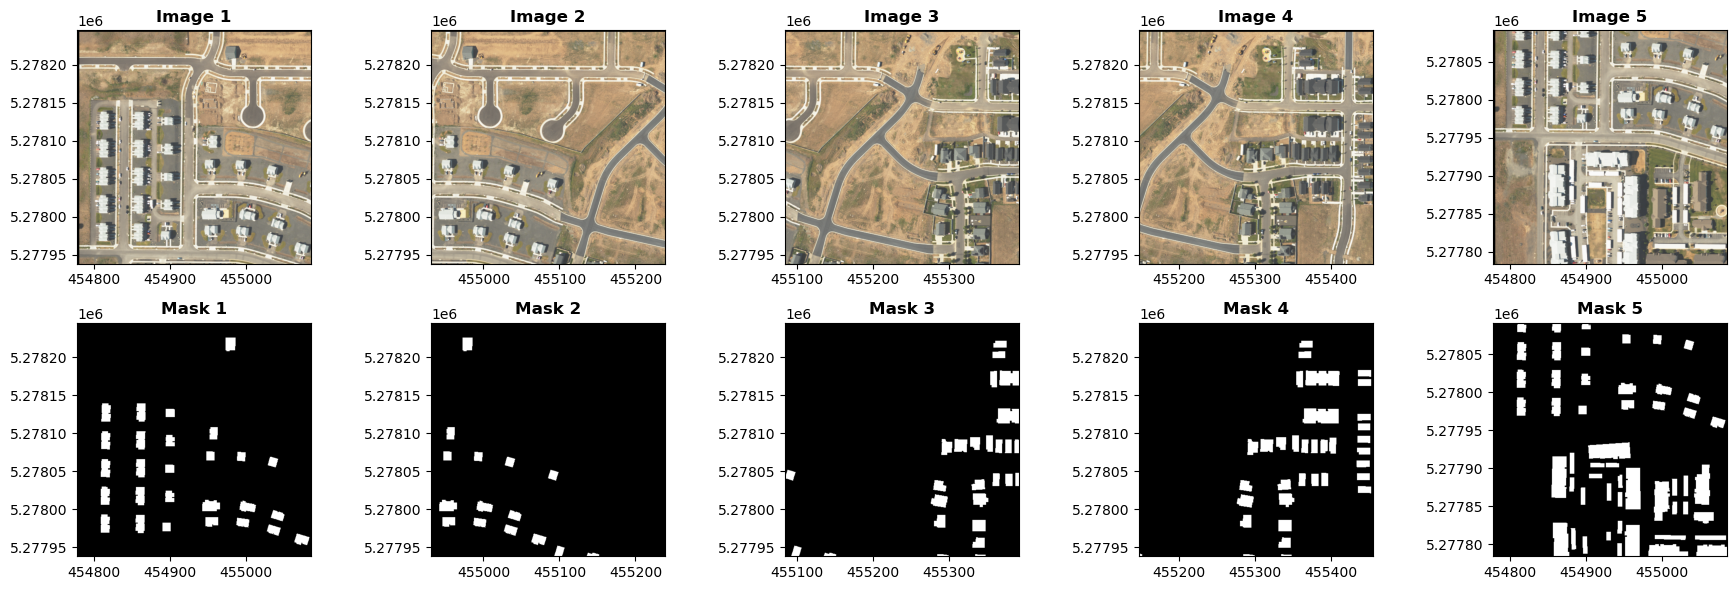

In [ ]:
# Visualizar algunos de los mosaicos generados
output_path = f"{train_path}/output"
fig = geoai.display_training_tiles(output_path, num_tiles=5)